----
----

In [77]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Read and prepare the data
data = pd.read_csv("Credit_N400_p9.csv")
X_df = data.copy(deep=True)
y_df = X_df.pop("Balance")

# Convert categorical variables to dummy variables
X_df = pd.get_dummies(X_df, columns=["Gender"], drop_first=True, dtype=int)
X_df = pd.get_dummies(X_df, columns=["Married"], drop_first=True, dtype=int)
X_df = pd.get_dummies(X_df, columns=["Student"], drop_first=True, dtype=int)

# Standardize features and center response
y_standardized = y_df - y_df.mean()
X_standardized = (X_df - X_df.mean()) / X_df.std()

# Initialize parameters
N = len(X_standardized)
p = X_standardized.shape[1]
max_iter = 1000
k_fold = 5
n_splits = N // k_fold

# Convert to numpy arrays
X = X_standardized.to_numpy()
y = y_standardized.to_numpy()

# Define tuning parameters
lambda_values = np.array([1e-2, 1e-1, 1e0, 1e1, 1e2, 1e3, 1e4, 1e5, 1e6])
lambda_log_values = np.log10(lambda_values)
alpha_values = np.array([0, 0.2, 0.4, 0.6, 0.8, 1.0])

# Precompute b_k values for full dataset
b_k = np.sum(X**2, axis=0)

# Initialize arrays
all_betas = np.zeros((len(alpha_values), len(lambda_values), p))
cv_errors = np.zeros((len(alpha_values), len(lambda_values)))

# For each combination of alpha and lambda
for i, alpha in enumerate(alpha_values):
    for j, lambda_val in enumerate(lambda_values):
        fold_errors = []
        
        # 5-fold cross validation
        for fold in range(k_fold):
            # Create indices for this fold
            all_indices = np.arange(N)
            val_indices = np.arange(fold * n_splits, (fold + 1) * n_splits)
            train_indices = np.array([idx for idx in all_indices if idx not in val_indices])
            
            # Split data
            X_train = X[train_indices]
            y_train = y[train_indices]
            X_val = X[val_indices]
            y_val = y[val_indices]
            
            # Calculate b_k for training data
            b_k_train = np.sum(X_train**2, axis=0)
            
            # Initialize beta
            beta = np.random.uniform(-1, 1, p)
            
            # Coordinate descent iterations
            for _ in range(max_iter):
                for k in range(p):
                    r_k = y_train - X_train.dot(beta) + X_train[:, k] * beta[k]
                    a_k = X_train[:, k].dot(r_k)
                    
                    if a_k > lambda_val * (1 - alpha) / 2:
                        beta[k] = (a_k - lambda_val * (1 - alpha) / 2) / (b_k_train[k] + lambda_val * alpha)
                    elif a_k < -lambda_val * (1 - alpha) / 2:
                        beta[k] = (a_k + lambda_val * (1 - alpha) / 2) / (b_k_train[k] + lambda_val * alpha)
                    else:
                        beta[k] = 0
            
            # Calculate validation error
            y_val_pred = X_val.dot(beta)
            mse = np.mean((y_val - y_val_pred)**2)
            fold_errors.append(mse)
        
        # Store average CV error
        cv_errors[i, j] = np.mean(fold_errors)
        
        # After CV, train on full dataset for coefficient paths
        beta_full = np.random.uniform(-1, 1, p)
        for _ in range(max_iter):
            for k in range(p):
                r_k = y - X.dot(beta_full) + X[:, k] * beta_full[k]
                a_k = X[:, k].dot(r_k)
                
                if a_k > lambda_val * (1 - alpha) / 2:
                    beta_full[k] = (a_k - lambda_val * (1 - alpha) / 2) / (b_k[k] + lambda_val * alpha)
                elif a_k < -lambda_val * (1 - alpha) / 2:
                    beta_full[k] = (a_k + lambda_val * (1 - alpha) / 2) / (b_k[k] + lambda_val * alpha)
                else:
                    beta_full[k] = 0
        
        all_betas[i, j, :] = beta_full

# Feature names for plots
feature_names = ['Income', 'Limit', 'Rating', 'Cards', 'Age', 'Education', 
                 'Gender_Male', 'Married_Yes', 'Student_Yes']

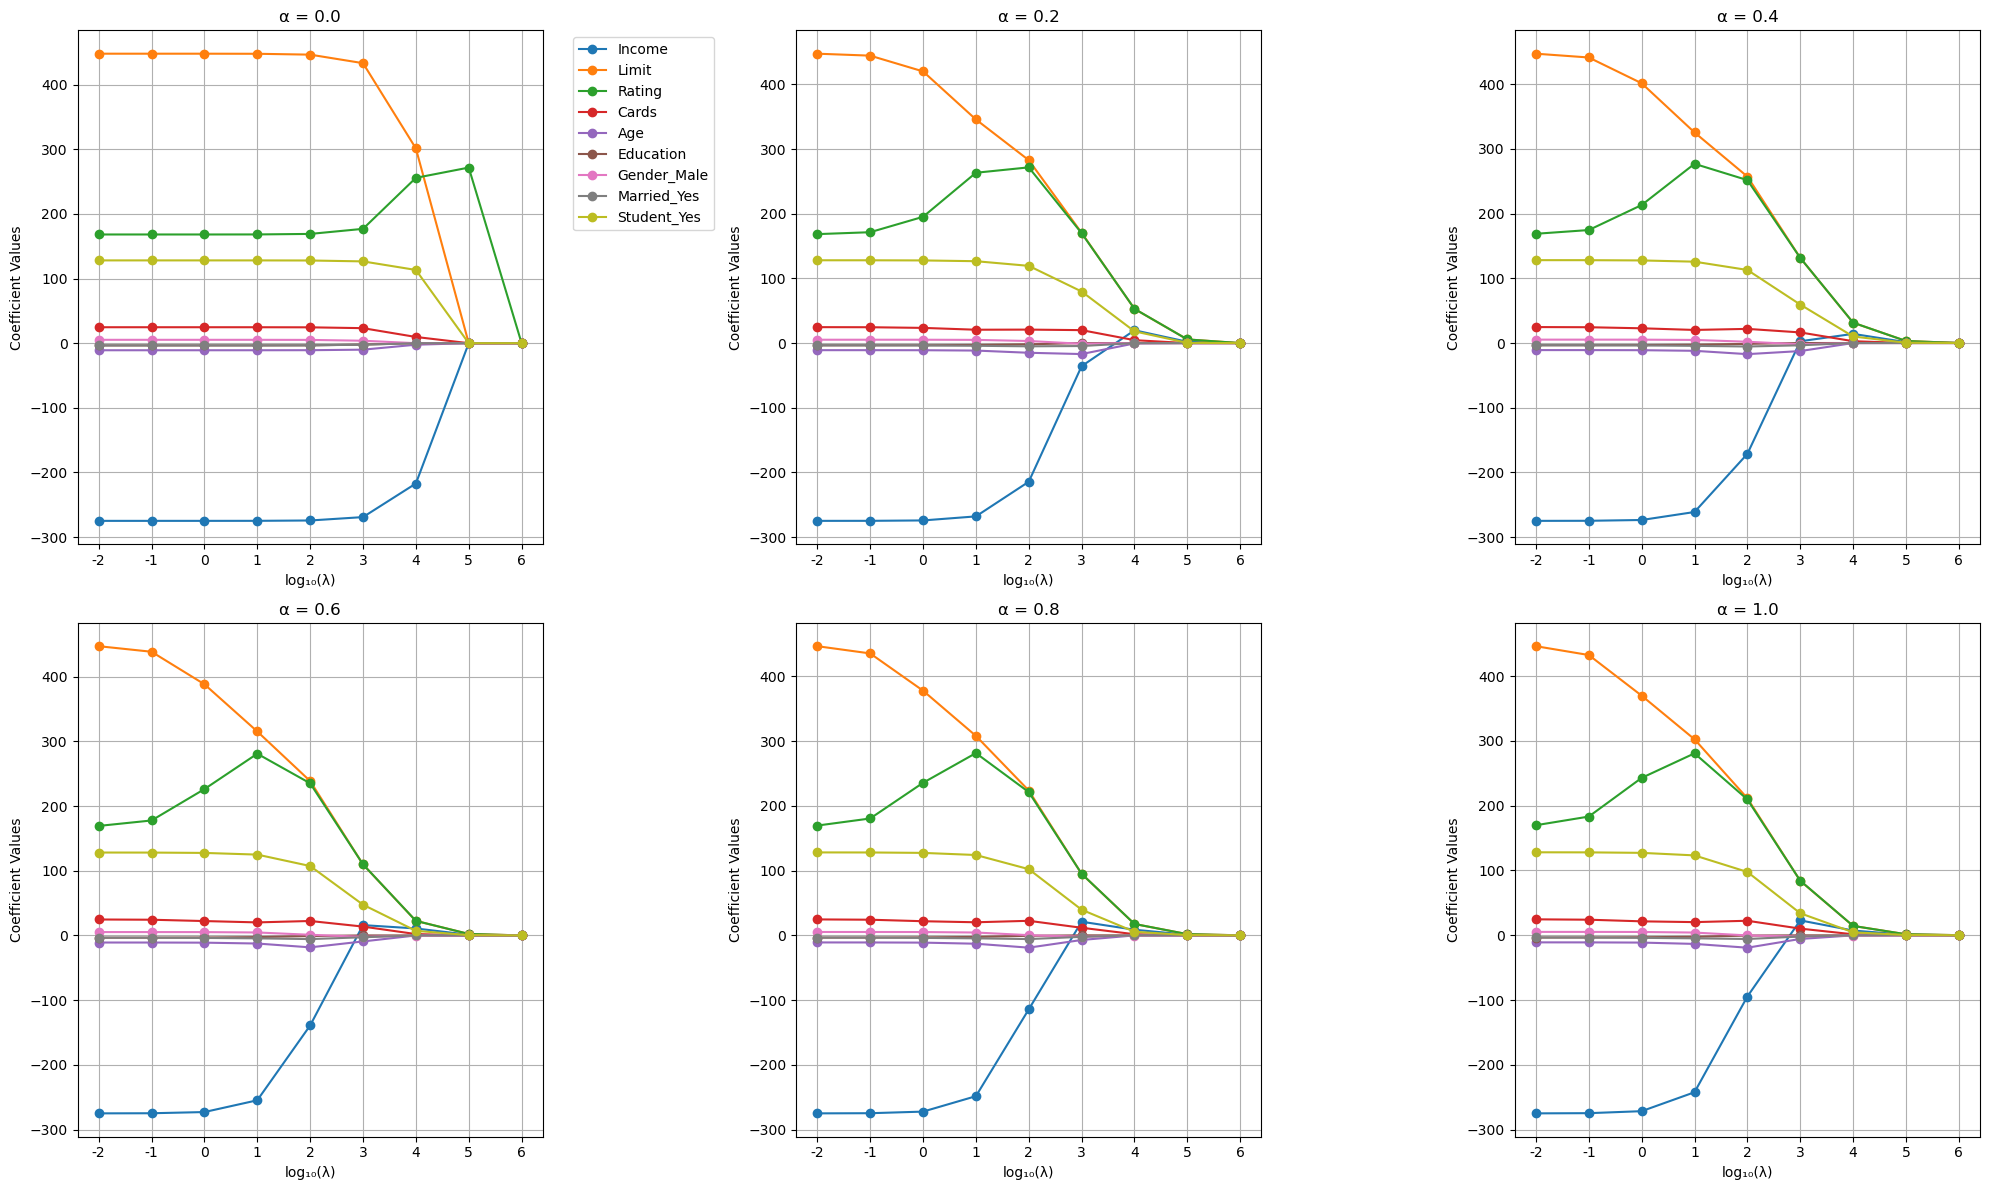

In [79]:
# Plot Deliverable 1: Coefficient paths

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.ravel()

for i, alpha in enumerate(alpha_values):
    ax = axes[i]
    for j in range(p):
        ax.plot(lambda_log_values, all_betas[i, :, j], label=feature_names[j], marker='o')
    
    ax.set_xlabel('log₁₀(λ)')
    ax.set_ylabel('Coefficient Values')
    ax.set_title(f'α = {alpha:.1f}')
    ax.grid(True)
    ax.set_xticks(lambda_log_values)
    ax.set_xticklabels([f'{x:.0f}' for x in lambda_log_values])
    
    if i == 0:
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

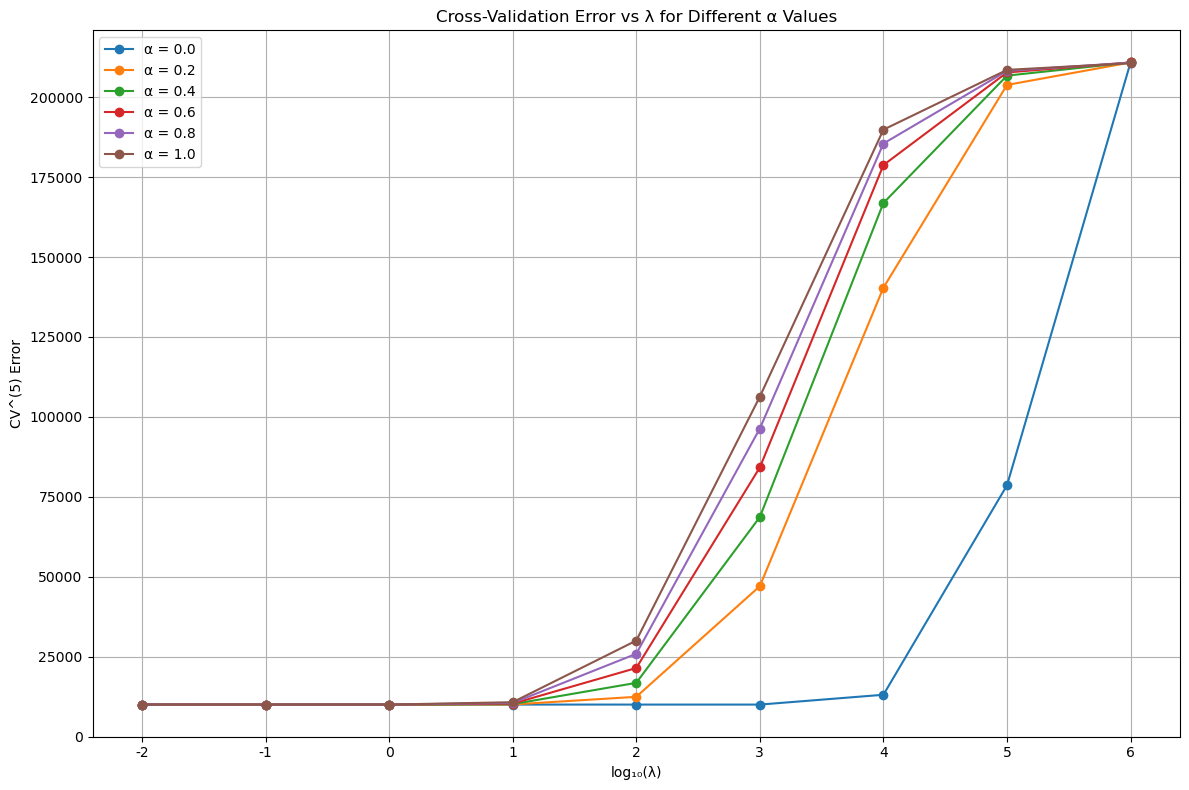

In [81]:
# Plot Deliverable 2: CV error

plt.figure(figsize=(12, 8))

for i, alpha in enumerate(alpha_values):
    plt.plot(lambda_log_values, cv_errors[i, :], 
             label=f'α = {alpha:.1f}', 
             marker='o')

plt.xlabel('log₁₀(λ)')
plt.ylabel('CV^(5) Error')
plt.title('Cross-Validation Error vs λ for Different α Values')
plt.grid(True)
plt.legend()
plt.xticks(lambda_log_values, [f'{x:.0f}' for x in lambda_log_values])

plt.tight_layout()
plt.show()


In [93]:
# Deliverable 3
# Find optimal parameters
min_error_idx = np.unravel_index(np.argmin(cv_errors), cv_errors.shape)
optimal_alpha = alpha_values[min_error_idx[0]]
optimal_lambda = lambda_values[min_error_idx[1]]

print(f"Optimal α value: {optimal_alpha:.1f}")
print(f"Optimal λ value: {optimal_lambda:.2e}")
print(f"Minimum CV^(5) error: {cv_errors[min_error_idx]:.4f}")

Optimal α value: 0.4
Optimal λ value: 1.00e+00
Minimum CV^(5) error: 10032.9347


In [95]:
#Deliverable 4

# I am training model with optimal parameters (elastic net)
beta_optimal = all_betas[min_error_idx[0], min_error_idx[1], :]

# I am training model with ridge regression (α = 1)
ridge_idx = np.where(alpha_values == 1.0)[0][0]
optimal_ridge_idx = np.argmin(cv_errors[ridge_idx, :])
beta_ridge = all_betas[ridge_idx, optimal_ridge_idx, :]

# I am training model with lasso (α = 0)
lasso_idx = np.where(alpha_values == 0.0)[0][0]
optimal_lasso_idx = np.argmin(cv_errors[lasso_idx, :])
beta_lasso = all_betas[lasso_idx, optimal_lasso_idx, :]

# Print results
print("\nBest-fit model parameters comparison:")
print("\nFeature      Elastic Net    Ridge      Lasso")
print("-" * 50)
for i, feature in enumerate(feature_names):
    print(f"{feature:<12} {beta_optimal[i]:>10.4f} {beta_ridge[i]:>10.4f} {beta_lasso[i]:>10.4f}")


Best-fit model parameters comparison:

Feature      Elastic Net    Ridge      Lasso
--------------------------------------------------
Income        -273.6323  -274.6517  -269.1541
Limit          401.5948   432.6483   433.3433
Rating         213.3275   183.2543   176.9292
Cards           22.7577    24.0359    23.2481
Age            -11.0984   -10.9877   -10.0538
Education       -3.2377    -3.4127    -2.1731
Gender_Male      5.1641     5.1965     3.7880
Married_Yes     -3.7410    -3.5171    -2.3760
Student_Yes    127.6709   127.9818   126.5723
